# fr-LN V3-2 Dataset Visualization
This notebook is used to visualize the dataset, and to clean it when needed

## Library imports

In [113]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import Counter


## Import the data

In [114]:
JSON_PATH = "../data.json"
with open(JSON_PATH, "r", encoding="utf-8") as f:
    json_data = json.load(f)

# Don't extract the json's metadata
data = json_data["data"]

df = pd.DataFrame(data)

In [115]:
print(f"Name of the columns: \n      {df.columns}")
print(f"\nNaN per columns (total = {df.shape[0]}) : \n{df.isna().sum()}")


df["POS"].value_counts()

Name of the columns: 
      Index(['node_id', 'entry_id', 'name', 'lexnum', 'POS', 'usagenote',
       'usagenotevars', 'definition', 'actants', 'lf_dict', 'status', '%',
       'examples'],
      dtype='object')

NaN per columns (total = 29975) : 
node_id              0
entry_id             0
name                 0
lexnum           13395
POS                  0
usagenote        26398
usagenotevars    26398
definition       29799
actants          29952
lf_dict           3624
status               0
%                    0
examples             0
dtype: int64


POS
nom                                   14448
adjectif                               4861
verbe                                  4677
locution nominale                      1820
verbe pronominal                        858
adverbe                                 846
locution prépositionnelle               775
locution verbale                        716
préposition                             157
numéral                                 146
locution conjonctive                     97
phrase                                   82
interjection                             55
locution phrastique                      54
locution adjectivale                     50
syntagme nominal                         48
pronom                                   44
conjonction                              36
locution adverbiale                      26
syntagme prépositionnel                  21
construction lexicalisée                 14
adjectif déterminatif                    14
préfixe                     

We don't mind the lexnum nans, since it means that there is no polysemy for this specific lexical unit. Same for actants, definitions, usagenotesa and usagenotevars

### Lets visualize the data

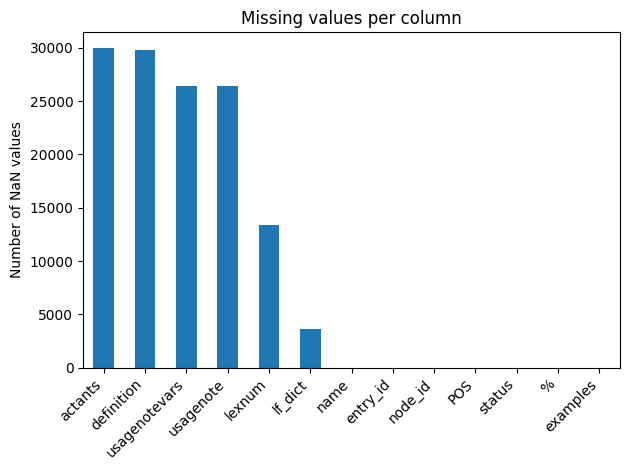

In [116]:
nan_counts = df.isna().sum().sort_values(ascending=False)

plt.figure()
nan_counts.plot(kind="bar")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of NaN values")
plt.title("Missing values per column")
plt.tight_layout()
plt.show()

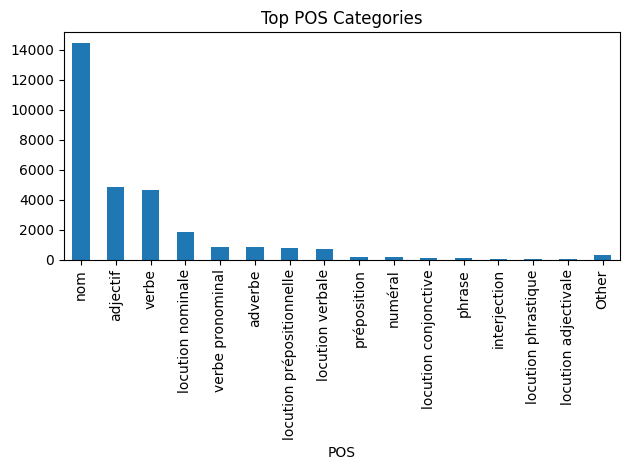

In [117]:
top_n = 15
pos_counts = df["POS"].value_counts()

top_pos = pos_counts.head(top_n)
other_sum = pos_counts.iloc[top_n:].sum()

plot_data = top_pos.copy()
plot_data["Other"] = other_sum

plt.figure()
plot_data.plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Top POS Categories")
plt.tight_layout()
plt.show()

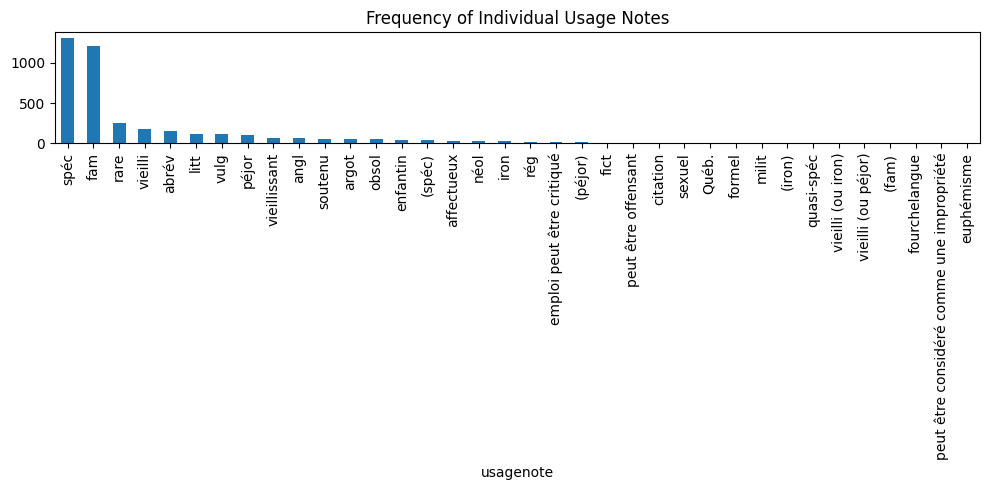

In [118]:
usagenotes_exploded = df["usagenote"].explode()

plt.figure(figsize=(10, 5))
usagenotes_exploded.value_counts().plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Frequency of Individual Usage Notes")
plt.tight_layout()
plt.show()

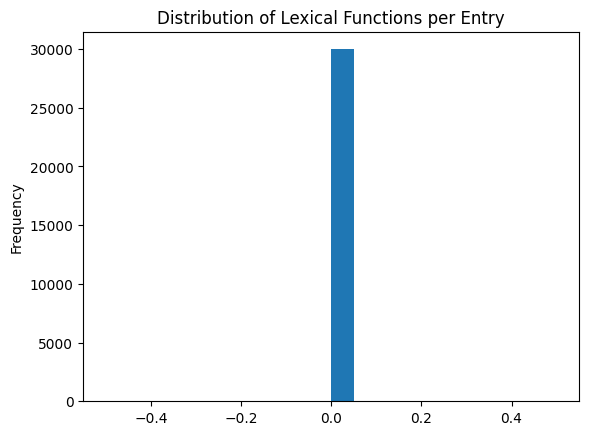

In [119]:
df["lf_count"] = df["lf_dict"].apply(
    lambda x: len(x) if isinstance(x, dict) else 0
)

plt.figure()
df["lf_count"].plot(kind="hist", bins=20)
plt.title("Distribution of Lexical Functions per Entry")
plt.show()

### Create a DF with the exploded lexical functions

In [120]:
df_lf = df.copy()
df_lf["lf_dict"] = df["lf_dict"].apply(lambda x: x if isinstance(x, list) else [])

df_lf = df_lf.explode("lf_dict")
lf_exanded = pd.json_normalize(df_lf["lf_dict"])

df_lf = pd.concat([
    df_lf[["node_id", "entry_id", "name", "lexnum", "POS"]].reset_index(drop=True),
    lf_exanded.reset_index(drop=True)
], axis=1)

lf_counts = df_lf["lexical_function"].value_counts()
(lf_counts >= 100).sum()
df_lf

,node_id,entry_id,name,lexnum,POS,lexical_function,linktype,target
0,ls:fr:node:26162,ls:fr:entry:26164,à,I.1,préposition,Syn_∩,paradigmatic,en direction
1,ls:fr:node:26162,ls:fr:entry:26164,à,I.1,préposition,Syn_∩,paradigmatic,sur
2,ls:fr:node:26162,ls:fr:entry:26164,à,I.1,préposition,Syn_∩,paradigmatic,vers
3,ls:fr:node:26163,ls:fr:entry:26165,à propos,1,locution prépositionnelle,Syn_∩,paradigmatic,au sujet
4,ls:fr:node:26163,ls:fr:entry:26165,à propos,1,locution prépositionnelle,Syn_∩,paradigmatic,concernant
...,...,...,...,...,...,...,...,...
70185,ls:fr:node:57164,ls:fr:entry:45432,non fonctionnel,None,syntagme adjectival,Anti,paradigmatic,fonctionnel
70186,ls:fr:node:57165,ls:fr:entry:45433,joncher,None,verbe,Syn_∩,paradigmatic,recouvrir
70187,ls:fr:node:57165,ls:fr:entry:45433,joncher,None,verbe,A_2,paradigmatic,jonché
70188,ls:fr:node:57166,ls:fr:entry:45434,jonché,None,adjectif,Syn_∩,paradigmatic,couvert


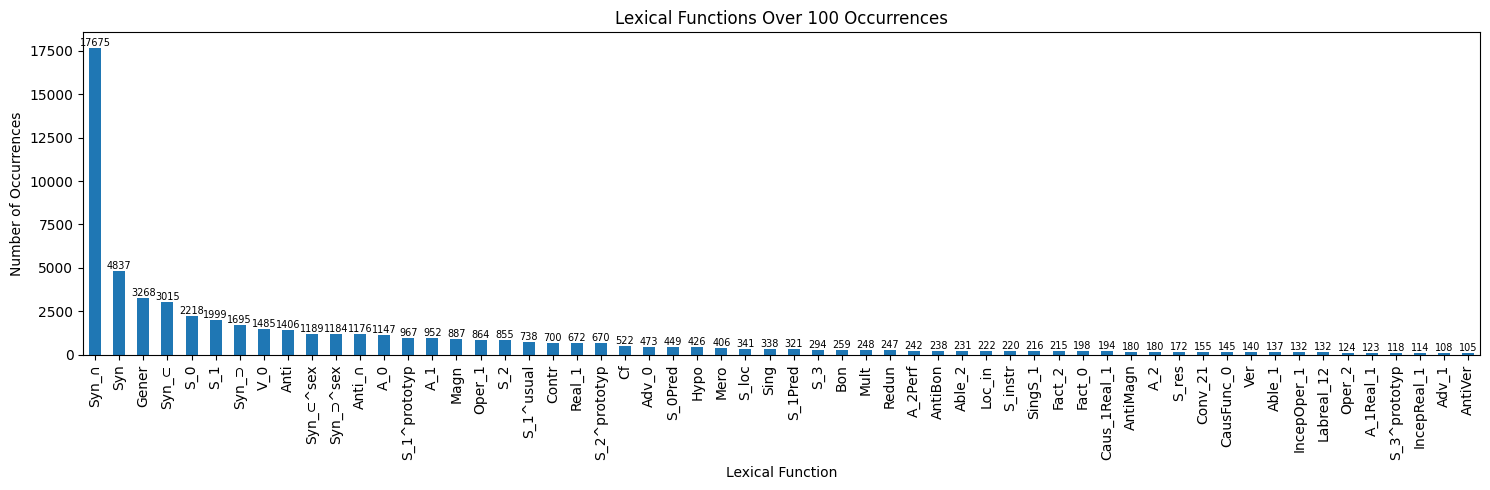

lexical_function
Syn_∩             17675
Syn                4837
Gener              3268
Syn_⊂              3015
S_0                2218
                  ...  
S_0IncepFact_1        1
S_0FinFact_Ω          1
S_0LiquFact_0         1
Qual_1[1]             1
ClausFinOper_1        1
Name: count, Length: 721, dtype: int64

In [121]:
lf_counts = df_lf["lexical_function"].value_counts()

rare_lf = lf_counts[lf_counts > 100]

plt.figure(figsize=(15, 5))
ax = rare_lf.plot(kind="bar")
plt.xticks(rotation=90)
#plt.yscale("log")
plt.ylabel("Number of Occurrences")
plt.xlabel("Lexical Function")

# Add numbers above bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.title("Lexical Functions Over 100 Occurrences")
plt.tight_layout()
plt.show()
lf_counts

Now, in `df_filtered`, only the LFs with more than 100 occurences are kept. That makes for 58 lexical functions.

Ideas : 
- Remove complexe LFs, like `Syn` variantions or LF compositions?
- Test models on removed LFs?

In [122]:
# Step 1: Count occurrences of each LF across all entries
all_lfs = [
    lf.get("lexical_function")
    for lf_list in df["lf_dict"]
    if isinstance(lf_list, list)
    for lf in lf_list
    if lf.get("lexical_function")
]

lf_counts = Counter(all_lfs)

# Keep LFs that appear at least 100 times
lf_threshold = {lf for lf, count in lf_counts.items() if count >= 100}
print(len(lf_threshold))
print(f"Lexical functions with at least 100 occurrences: {sorted(lf_threshold)}\n")

# Step 2: Extract combinations of LFs above the threshold per entry
filtered_combinations = []

for lf_list in df["lf_dict"]:
    if isinstance(lf_list, list) and len(lf_list) > 0:
        # Keep only LFs that meet the threshold
        filtered_lfs = [lf.get("lexical_function") for lf in lf_list if lf.get("lexical_function") in lf_threshold]
        if filtered_lfs:
            combo = tuple(sorted(filtered_lfs))
            filtered_combinations.append(combo)

# Count combinations
combo_counts = Counter(filtered_combinations)

# Print sorted by frequency
print("LF combinations (with threshold applied) and their counts:\n")
for combo, count in combo_counts.most_common():
    print(combo, ":", count)

58
Lexical functions with at least 100 occurrences: ['A_0', 'A_1', 'A_1Real_1', 'A_2', 'A_2Perf', 'Able_1', 'Able_2', 'Adv_0', 'Adv_1', 'Anti', 'AntiBon', 'AntiMagn', 'AntiVer', 'Anti_∩', 'Bon', 'CausFunc_0', 'Caus_1Real_1', 'Cf', 'Contr', 'Conv_21', 'Fact_0', 'Fact_2', 'Gener', 'Hypo', 'IncepOper_1', 'IncepReal_1', 'Labreal_12', 'Loc_in', 'Magn', 'Mero', 'Mult', 'Oper_1', 'Oper_2', 'Real_1', 'Redun', 'S_0', 'S_0Pred', 'S_1', 'S_1Pred', 'S_1^prototyp', 'S_1^usual', 'S_2', 'S_2^prototyp', 'S_3', 'S_3^prototyp', 'S_instr', 'S_loc', 'S_res', 'Sing', 'SingS_1', 'Syn', 'Syn_∩', 'Syn_⊂', 'Syn_⊂^sex', 'Syn_⊃', 'Syn_⊃^sex', 'V_0', 'Ver']

LF combinations (with threshold applied) and their counts:

('Syn_∩',) : 5477
('Syn_∩', 'Syn_∩') : 1188
('Syn_⊂',) : 1161
('S_0',) : 856
('V_0',) : 805
('Syn_⊂^sex',) : 750
('Syn',) : 714
('Gener',) : 694
('Syn_⊃^sex',) : 621
('Anti',) : 567
('Syn_∩', 'Syn_∩', 'Syn_∩') : 320
('A_0',) : 318
('Anti_∩',) : 303
('Syn_∩', 'Syn_⊂') : 239
('Syn_⊃',) : 213
('A_1',) :

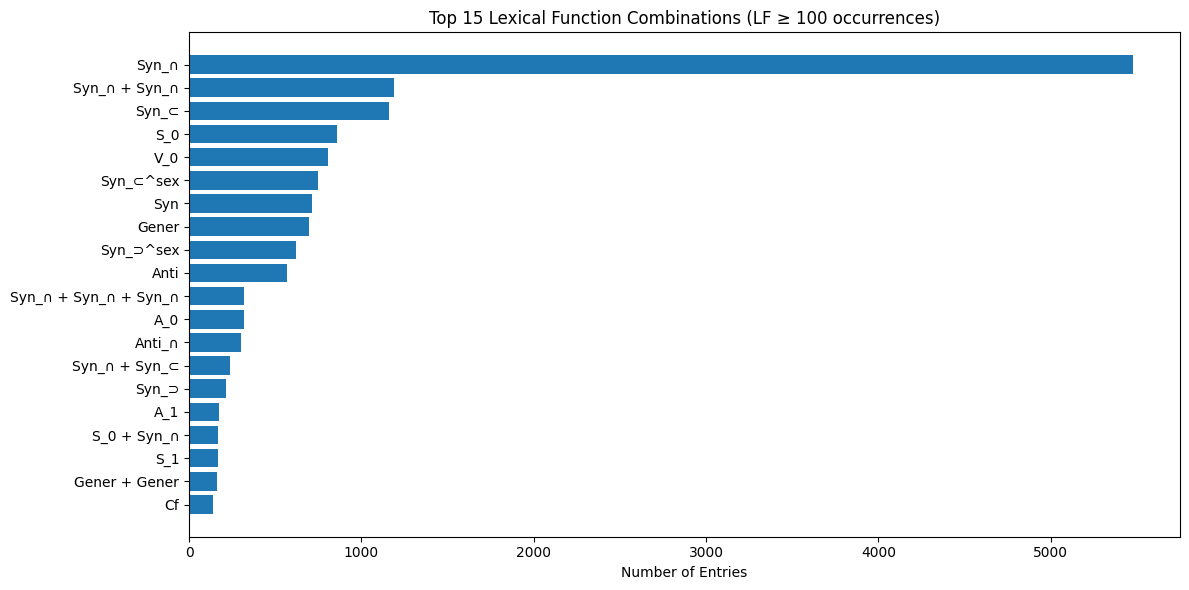

In [123]:
top_combos = combo_counts.most_common(20)

# Prepare data for plotting
combos, counts = zip(*top_combos)
combo_labels = [' + '.join(combo) for combo in combos]  # make readable labels

# Plot
plt.figure(figsize=(12, 6))
plt.barh(combo_labels[::-1], counts[::-1])  # reverse for top at top
plt.xlabel("Number of Entries")
plt.title("Top 15 Lexical Function Combinations (LF ≥ 100 occurrences)")
plt.tight_layout()
plt.show()

In [124]:
# Step 2: Filter each row's lf_dict
def filter_lf_list(lf_list, threshold_set):
    if not isinstance(lf_list, list):
        return []  # if not a list, return empty
    return [lf for lf in lf_list if lf.get("lexical_function") in threshold_set]

df_filtered = df.copy()
df_filtered["lf_dict"] = df_filtered["lf_dict"].apply(lambda x: filter_lf_list(x, lf_threshold))

# Optional: remove rows that have no remaining LFs after filtering
df_filtered_nonempty = df_filtered[df_filtered["lf_dict"].map(len) > 0]

print(f"Original rows: {len(df)}")
print(f"Rows remaining after LF filter: {len(df_filtered_nonempty)}")

Original rows: 29975
Rows remaining after LF filter: 25750


### Examples for the rows with the kept LFs

In [125]:
# Remove rows without examples
df_filtered_nonempty = df_filtered_nonempty[df_filtered_nonempty["examples"].map(len) != 0]
df_filtered_nonempty

,node_id,entry_id,name,lexnum,POS,usagenote,usagenotevars,definition,actants,lf_dict,status,%,examples,lf_count
0,ls:fr:node:26162,ls:fr:entry:26164,à,I.1,préposition,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'C’est comme de changer d’avion à Mi...,0
1,ls:fr:node:26163,ls:fr:entry:26165,à propos,1,locution prépositionnelle,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,"[{'text': 'Le docteur Ricci, que maman m’avait...",0
2,ls:fr:node:26164,ls:fr:entry:26166,abandonner,II.2,verbe,None,None,None,None,"[{'lexical_function': 'S_0', 'linktype': 'para...",2,100,[{'text': 'Pourtant un jour elle partit et aba...,0
3,ls:fr:node:26166,ls:fr:entry:26168,abîme,I,nom,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'De nombreux Constantinois allaient ...,0
4,ls:fr:node:26167,ls:fr:entry:26169,abîmer,I,verbe,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,"[{'text': '« On remplit au fur et à mesure, s’...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29970,ls:fr:node:57162,ls:fr:entry:45431,fonctionnel,1,adjectif,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'Les petits jouent à s’identifier au...,0
29971,ls:fr:node:57163,ls:fr:entry:45431,fonctionnel,2,adjectif,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'L’intérieur fonctionnel n’est pas p...,0
29972,ls:fr:node:57164,ls:fr:entry:45432,non fonctionnel,None,syntagme adjectival,None,None,None,None,"[{'lexical_function': 'Anti', 'linktype': 'par...",2,100,"[{'text': 'Tant que la personne tient debout, ...",0
29973,ls:fr:node:57165,ls:fr:entry:45433,joncher,None,verbe,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'Certains passants souvent étonnés d...,0


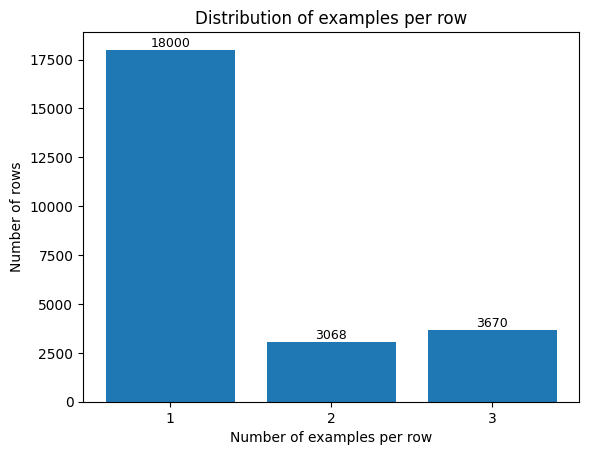

In [126]:
df_filtered_nonempty["n_examples"] = df_filtered_nonempty["examples"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
# Count how many rows have 1,2,3,... examples
counts = df_filtered_nonempty["n_examples"].value_counts().sort_index()


bars = plt.bar(counts.index, counts.values)
plt.xlabel("Number of examples per row")
plt.ylabel("Number of rows")
plt.title("Distribution of examples per row")
plt.xticks(counts.index)  # show integers
# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.show()

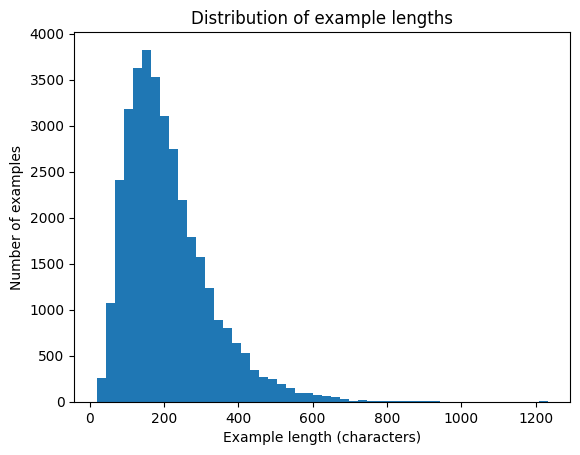

In [127]:
# Visualize the length of the examples
example_lengths = [
    len(ex["text"])
    for ex_list in df_filtered_nonempty["examples"]
    if isinstance(ex_list, list)
    for ex in ex_list
    if "text" in ex
]
plt.hist(example_lengths, bins=50)

plt.xlabel("Example length (characters)")
plt.ylabel("Number of examples")
plt.title("Distribution of example lengths")

plt.show()

In [128]:
print("Number of examples:", len(example_lengths))
print("Average length:", np.mean(example_lengths))
print("Median length:", np.median(example_lengths))
print("Max length:", np.max(example_lengths))
print("Min length:", np.min(example_lengths))
df_filtered_nonempty

Number of examples: 35146
Average length: 211.78085699652877
Median length: 187.0
Max length: 1233
Min length: 20


,node_id,entry_id,name,lexnum,POS,usagenote,usagenotevars,definition,actants,lf_dict,status,%,examples,lf_count,n_examples
0,ls:fr:node:26162,ls:fr:entry:26164,à,I.1,préposition,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'C’est comme de changer d’avion à Mi...,0,3
1,ls:fr:node:26163,ls:fr:entry:26165,à propos,1,locution prépositionnelle,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,"[{'text': 'Le docteur Ricci, que maman m’avait...",0,2
2,ls:fr:node:26164,ls:fr:entry:26166,abandonner,II.2,verbe,None,None,None,None,"[{'lexical_function': 'S_0', 'linktype': 'para...",2,100,[{'text': 'Pourtant un jour elle partit et aba...,0,1
3,ls:fr:node:26166,ls:fr:entry:26168,abîme,I,nom,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'De nombreux Constantinois allaient ...,0,1
4,ls:fr:node:26167,ls:fr:entry:26169,abîmer,I,verbe,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,"[{'text': '« On remplit au fur et à mesure, s’...",0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29970,ls:fr:node:57162,ls:fr:entry:45431,fonctionnel,1,adjectif,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'Les petits jouent à s’identifier au...,0,1
29971,ls:fr:node:57163,ls:fr:entry:45431,fonctionnel,2,adjectif,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'L’intérieur fonctionnel n’est pas p...,0,1
29972,ls:fr:node:57164,ls:fr:entry:45432,non fonctionnel,None,syntagme adjectival,None,None,None,None,"[{'lexical_function': 'Anti', 'linktype': 'par...",2,100,"[{'text': 'Tant que la personne tient debout, ...",0,1
29973,ls:fr:node:57165,ls:fr:entry:45433,joncher,None,verbe,None,None,None,None,"[{'lexical_function': 'Syn_∩', 'linktype': 'pa...",2,100,[{'text': 'Certains passants souvent étonnés d...,0,3


In [129]:
import re

WINDOW = 60

def best_and_short_example(ex_list):

    if not isinstance(ex_list, list) or len(ex_list) == 0:
        return None

    best_ex = min(ex_list, key=lambda x: x.get("position", float("inf")))

    text = best_ex.get("text", "")
    occ = best_ex.get("occurrence", "")

    numbers = list(map(int, re.findall(r"\d+", occ)))

    if len(numbers) < 2:
        return text

    start, end = numbers[0], numbers[1]

    left = max(0, start - WINDOW)
    right = min(len(text), end + WINDOW)

    # expand left to word boundary
    while left > 0 and text[left] not in [" ", "\n"]:
        left -= 1

    # expand right to word boundary
    while right < len(text) and text[right] not in [" ", "\n"]:
        right += 1

    short_text = text[left:right].strip()

    if left > 0:
        short_text = "..." + short_text
    if right < len(text):
        short_text = short_text + "..."

    return short_text


df_filtered_nonempty["examples_short"] = df_filtered_nonempty["examples"].apply(best_and_short_example)

In [130]:
df_filtered_nonempty["examples_short"][0]

'...comme de changer d’avion à Milan pour aller à Palerme.'

## Split the data into train/valid/test
- Using 80/10/10
- Grouping the data by `(name, lexical_function)`
- Stratification by `lexical_function` to make sure all 3 sets have the same amounts of each LF

### 1. Flatten the LFs
One row per prediuction example

In [131]:
rows = []

for _, row in df_filtered_nonempty.iterrows():
    name = row["name"]
    pos = row["POS"]
    example = row["examples_short"]

    for lf in row["lf_dict"]:
        lf_name = lf.get("lexical_function")
        target = lf.get("target")

        if lf_name and target:
            rows.append({
                "name": name,
                "POS": pos,
                "lexical_function": lf_name,
                "target": target,
                "example": example
            })

df_flat = pd.DataFrame(rows)



### 2. Build groups

In [132]:
df_examples = (
    df_flat
    .drop_duplicates(subset=["name", "POS", "lexical_function"])
    [["name", "POS", "lexical_function", "example"]]
)

In [133]:
# Step 2: GROUP targets
fl_to_remove = ["Syn_∩", "Syn_⊂", "Syn_⊃^sex", "Syn_⊃", "Syn_⊂^sex", "Anti_∩", "S_1^prototyp", "S_0Pred", 
                "S_1^usual", "A_2Perf", "Caus_1Real_1", "S_2^prototyp", "S_1Pred", "S_3^prototyp", 
                "CausFunc_0", "SingS_1", "Labreal_12", "IncepOper_1", "A_1Real_1", "IncepReal_1", "Cf", "Oper_2"]

df_filtered = df_flat[~df_flat["lexical_function"].isin(fl_to_remove)]

df_grouped = (
    df_filtered
    .groupby(["name", "POS", "lexical_function"])["target"]
    .apply(lambda x: sorted(set(x)))
    .reset_index()
    .rename(columns={"target": "targets"})
)

df_grouped = df_grouped.merge(
    df_examples,
    on=["name", "POS", "lexical_function"],
    how="left"
)

df_grouped["lexical_function"].value_counts()

lexical_function
Gener       2038
Syn         1811
S_0         1658
Anti        1043
V_0         1024
S_1          973
A_0          939
A_1          694
S_2          508
Contr        503
Adv_0        398
Oper_1       379
Real_1       296
Magn         284
Able_2       203
S_loc        203
Redun        183
S_3          176
Mero         156
Sing         156
Mult         148
A_2          145
Hypo         125
Able_1       123
S_res        119
S_instr      115
Conv_21      112
AntiBon      111
Fact_0       108
Fact_2       101
Bon           92
AntiMagn      89
Adv_1         78
Loc_in        73
Ver           71
AntiVer       65
Name: count, dtype: int64

In [134]:
# Remove lots of examples to have 6250 in total
import numpy as np

MAX_SIZE = 12000
MIN_PER_CLASS = 40  # tweak (30–50 works well)

counts = df_grouped["lexical_function"].value_counts()
total = counts.sum()

# Option: log-scaling (recommended)
weights = np.log1p(counts)
proportions = weights / weights.sum()

quotas = (proportions * MAX_SIZE).round().astype(int)
quotas = quotas.clip(lower=MIN_PER_CLASS)

# Adjust to exact budget
while quotas.sum() > MAX_SIZE:
    largest = quotas.idxmax()
    quotas[largest] -= 1

# Apply sampling
df_grouped = (
    df_grouped
    .groupby("lexical_function", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), quotas[x.name]), random_state=42))
    .reset_index(drop=True)
)
df_grouped["lexical_function"].value_counts()

/tmp/ipykernel_16786/942116680.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), quotas[x.name]), random_state=42))


lexical_function
Gener       459
Syn         455
S_0         450
Anti        422
V_0         421
S_1         418
A_0         416
A_1         397
Contr       378
S_2         378
Adv_0       364
Oper_1      361
Real_1      296
Magn        284
S_loc       203
Able_2      203
Redun       183
S_3         176
Sing        156
Mero        156
Mult        148
A_2         145
Hypo        125
Able_1      123
S_res       119
S_instr     115
Conv_21     112
AntiBon     111
Fact_0      108
Fact_2      101
Bon          92
AntiMagn     89
Adv_1        78
Loc_in       73
Ver          71
AntiVer      65
Name: count, dtype: int64

### 3. Create a group-level dataframe

In [135]:
df_grouped["group_id"] = (
    df_grouped["name"] + "||" +
    df_grouped["POS"] + "||" +
    df_grouped["lexical_function"]
)

In [136]:
import random

df_grouped["targets"] = df_grouped["targets"].apply(
    lambda x: random.sample(x, len(x))
)

###  4. Stratified group split

In [137]:
from sklearn.model_selection import train_test_split

unique_words = df_grouped["name"].unique()

train_words, unseen_words = train_test_split(
    unique_words,
    test_size=0.2,
    random_state=42
)

df_seen = df_grouped[df_grouped["name"].isin(train_words)].reset_index(drop=True)
df_unseen = df_grouped[df_grouped["name"].isin(unseen_words)].reset_index(drop=True)

group_df = df_seen[["group_id", "lexical_function"]].drop_duplicates()

# Train set
train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.2,
    stratify=group_df["lexical_function"],
    random_state=42
)

# Valid and Test sets
val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.5,
    stratify=temp_groups["lexical_function"],
    random_state=42
)

### 5. Map back to full dataset

In [138]:
train_ids = set(train_groups["group_id"])
val_ids = set(val_groups["group_id"])
test_ids = set(test_groups["group_id"])

df_train = df_seen[df_seen["group_id"].isin(train_ids)].reset_index(drop=True)
df_val   = df_seen[df_seen["group_id"].isin(val_ids)].reset_index(drop=True)
df_test  = df_seen[df_seen["group_id"].isin(test_ids)].reset_index(drop=True)

In [139]:
print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

# Check no leakage
assert len(set(df_train["group_id"]) & set(df_val["group_id"])) == 0
assert len(set(df_train["group_id"]) & set(df_test["group_id"])) == 0
assert len(set(df_val["group_id"]) & set(df_test["group_id"])) == 0

# Check LF distribution
print("\nLF distribution (train):")
print(df_train["lexical_function"].value_counts(normalize=True))

print("\nLF distribution (val):")
print(df_val["lexical_function"].value_counts(normalize=True))

print("\nLF distribution (test):")
print(df_test["lexical_function"].value_counts(normalize=True))

Train size: 5277
Val size: 660
Test size: 660

LF distribution (train):
lexical_function
S_0         0.055524
Syn         0.054766
Gener       0.054576
V_0         0.051734
Anti        0.051165
S_1         0.049839
A_0         0.048891
S_2         0.047375
A_1         0.046617
Adv_0       0.044533
Contr       0.044154
Oper_1      0.043964
Real_1      0.036574
Magn        0.034868
Able_2      0.025014
S_loc       0.024446
Redun       0.023877
S_3         0.021793
Sing        0.019708
Mero        0.019140
A_2         0.017055
Able_1      0.015918
Mult        0.015918
Hypo        0.014781
S_res       0.014781
Conv_21     0.014023
S_instr     0.013834
AntiBon     0.013265
Fact_2      0.012697
Fact_0      0.011939
Bon         0.010991
Adv_1       0.010233
AntiMagn    0.010233
Ver         0.009096
Loc_in      0.008717
AntiVer     0.007959
Name: proportion, dtype: float64

LF distribution (val):
lexical_function
S_0         0.056061
Gener       0.054545
Syn         0.054545
Anti        0.0515

### 6. Save splits

In [140]:
df_train.to_csv("train.csv", index=False)
df_val.to_csv("val.csv", index=False)
df_test.to_csv("test.csv", index=False)

# unseen generalization
df_unseen.to_csv("test_unseen_words.csv", index=False)